# 02 — Análise Exploratória (EDA)

Carregamos a Gold que o notebook 01 gerou e exploramos distribuições, padrões e correlações.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

gold = pd.read_parquet("../data/gold/gold_indicador_municipio.parquet")
print(gold.shape)
gold.head()

(15238, 30)


,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,...,meta_2028,meta_2029,meta_2030,nivel_alfabetizacao,percentual_participacao,rede_label,meta_ano_vigente,diferenca_meta,bateu_meta_2030,classificacao
0,2023,1100031,2,3,69.10,767.8763,NaN,NaN,NaN,NaN,...,77.21,78.64,80.0,3.0,90.48,Estadual,NaN,NaN,False,Sem meta definida
1,2023,1100072,2,3,58.20,747.8918,NaN,NaN,NaN,NaN,...,74.74,77.48,80.0,2.0,92.25,Estadual,NaN,NaN,False,Sem meta definida
2,2023,1100189,2,5,69.73,762.4062,NaN,NaN,NaN,NaN,...,77.36,78.71,80.0,3.0,90.35,Privada,NaN,NaN,False,Sem meta definida
3,2023,1101609,2,3,50.70,745.6802,NaN,NaN,NaN,NaN,...,73.07,76.71,80.0,2.0,95.00,Estadual,NaN,NaN,False,Sem meta definida
4,2023,1101807,2,3,55.69,752.3724,NaN,NaN,NaN,NaN,...,74.18,77.22,80.0,2.0,83.15,Estadual,NaN,NaN,False,Sem meta definida


## 2.1 Visão geral das variáveis

In [3]:
gold.describe().T

,count,mean,std,min,25%,50%,75%,max
ano,15238.0,2023.495669,0.499998,2023.0,2023.0,2023.0,2024.0,2024.0
id_municipio,15238.0,3317942.153104,978464.982629,1100015.0,2606531.75,3161601.0,4208955.0,5300108.0
serie,15238.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0
rede,15238.0,3.649298,1.19316,0.0,3.0,3.0,5.0,5.0
taxa_alfabetizacao,15238.0,61.636313,19.218081,2.12,48.0,62.355,76.13,100.0
media_portugues,15238.0,751.353487,22.482862,673.2983,736.87,750.7299,763.85705,868.4554
proporcao_aluno_nivel_0,7553.0,2.25175,2.739789,0.0,0.0,1.55,3.36,30.0
proporcao_aluno_nivel_1,7553.0,4.234505,4.226321,0.0,0.86,3.31,6.3,50.0
proporcao_aluno_nivel_2,7553.0,7.545802,6.197494,0.0,2.81,6.44,10.98,47.06
proporcao_aluno_nivel_3,7553.0,11.21013,7.181179,0.0,5.84,10.44,15.79,59.73


## 2.2 Nulos por coluna

`meta_ano_vigente`/`diferenca_meta` têm nulos em 2023 porque as metas só
existem a partir de 2024.

In [4]:
(gold.isna().mean() * 100).round(1).sort_values(ascending=False).to_frame("% nulos")

,% nulos
diferenca_meta,53.6
meta_ano_vigente,53.6
proporcao_aluno_nivel_3,50.4
proporcao_aluno_nivel_2,50.4
proporcao_aluno_nivel_5,50.4
proporcao_aluno_nivel_4,50.4
proporcao_aluno_nivel_6,50.4
proporcao_aluno_nivel_7,50.4
proporcao_aluno_nivel_1,50.4
proporcao_aluno_nivel_0,50.4


## 2.3 Distribuição da taxa de alfabetização

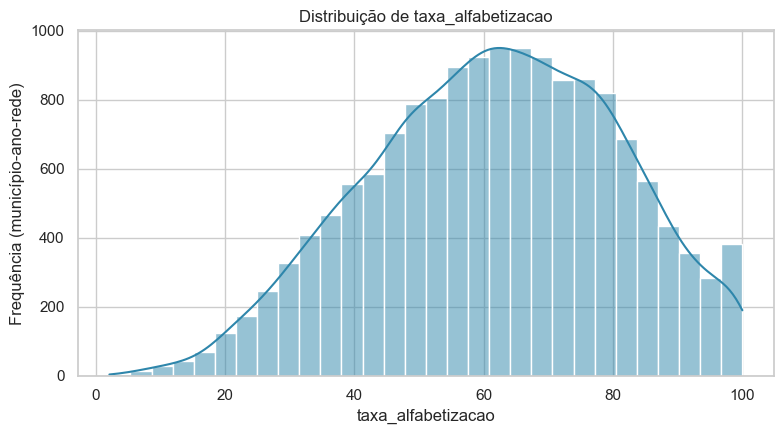

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(gold["taxa_alfabetizacao"].dropna(), bins=30, kde=True, color="#2E86AB", ax=ax)
ax.set_title("Distribuição de taxa_alfabetizacao")
ax.set_xlabel("taxa_alfabetizacao")
ax.set_ylabel("Frequência (município-ano-rede)")
plt.tight_layout()
plt.show()

**Leitura:** distribuição ampla, de perto de 0% a quase 100%, com maior
concentração na faixa de 55-75% — bastante heterogeneidade.

## 2.4 Distribuição por rede de ensino

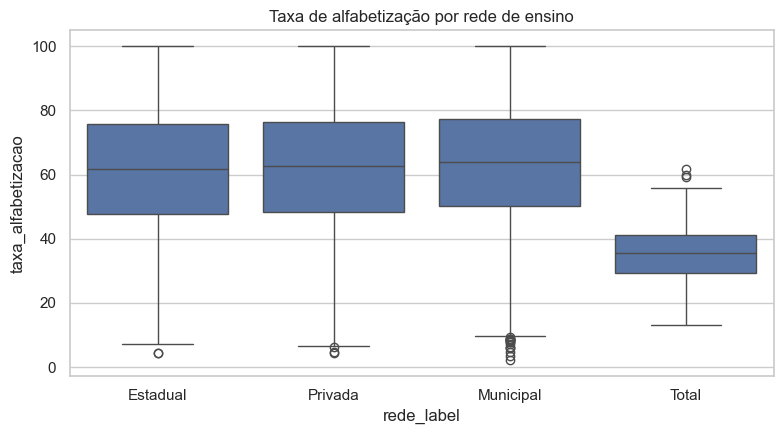

,count,mean,median,std
rede_label,,,,
Estadual,6727,61.237840,61.700,19.059965
Municipal,2176,63.156857,63.985,19.668569
Privada,6215,62.035052,62.800,19.007839
Total,120,35.750083,35.465,9.215601


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=gold, x="rede_label", y="taxa_alfabetizacao", ax=ax)
ax.set_title("Taxa de alfabetização por rede de ensino")
plt.tight_layout()
plt.show()

gold.groupby("rede_label")["taxa_alfabetizacao"].agg(["count", "mean", "median", "std"])

**Leitura:** mesmo após remover as duplicatas exatas (notebook 01), as
redes principais têm médias relativamente próximas nesta base. A categoria
"Total" (poucas linhas, só em 2024) se comporta de forma diferente.

## 2.5 Evolução da taxa média nacional (2023 → 2024)

           mean  median        std
ano                               
2023  60.866422   61.53  19.445310
2024  62.419658   63.31  18.953302


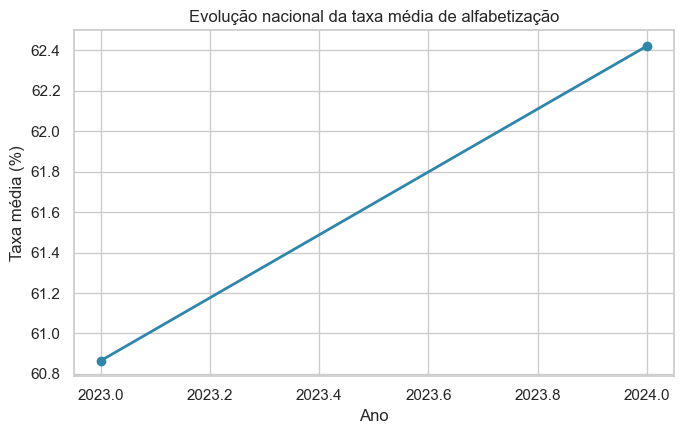

In [7]:
evolucao = gold.groupby("ano")["taxa_alfabetizacao"].agg(["mean", "median", "std"])
print(evolucao)

fig, ax = plt.subplots(figsize=(7, 4.5))
serie = gold.groupby("ano")["taxa_alfabetizacao"].mean()
ax.plot(serie.index, serie.values, marker="o", linewidth=2, color="#2E86AB")
ax.set_title("Evolução nacional da taxa média de alfabetização")
ax.set_xlabel("Ano")
ax.set_ylabel("Taxa média (%)")
plt.tight_layout()
plt.show()

**Leitura:** a taxa média nacional subiu de 2023 para 2024 — sinal
positivo, mas ainda distante da meta de 80% até 2030.

## 2.6 Correlação entre variáveis numéricas

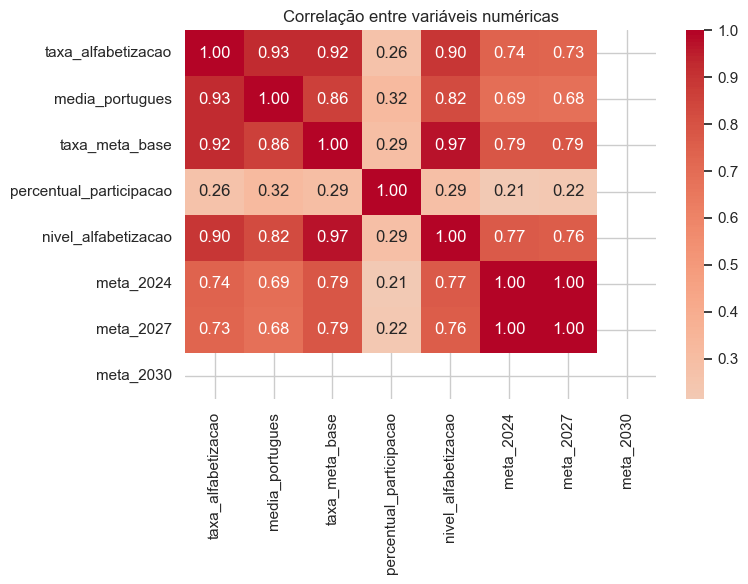

In [8]:
numeric_cols = [
    "taxa_alfabetizacao", "media_portugues", "taxa_meta_base",
    "percentual_participacao", "nivel_alfabetizacao",
    "meta_2024", "meta_2027", "meta_2030",
]

fig, ax = plt.subplots(figsize=(8, 6))
corr = gold[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

**Leitura importante para a modelagem (notebook 03):**
- `taxa_meta_base` (r ≈ 0.98) e `media_portugues` (r ≈ 0.93) são
  quase-cópias da própria `taxa_alfabetizacao` — não podem virar features
  do modelo (data leakage).
- `nivel_alfabetizacao` também é essencialmente um balde da taxa.
- `percentual_participacao` tem correlação baixa (~0.28) — feature legítima.
- As metas (`meta_2024`...`meta_2030`) têm correlação moderada (~0.80), mas
  são valores de política pública conhecidos a priori — podem ser feature.

## 2.7 Ranking de municípios: maior e menor taxa (2024)

**Base IBG - API pública** : O IBGE disponibiliza uma API gratuita e oficial com todos os municípios do Brasil (código + nome + UF). Vamos utilizar ela para identificação dos municípios e UFs da base.

In [9]:
import requests

resp = requests.get("https://servicodados.ibge.gov.br/api/v1/localidades/municipios")
municipios_ibge = pd.DataFrame(resp.json())[["id", "nome"]].rename(
    columns={"id": "id_municipio", "nome": "nome_municipio"}
)
print(municipios_ibge.shape)
municipios_ibge.head()

(5571, 2)


,id_municipio,nome_municipio
0,1100015,Alta Floresta D'Oeste
1,1100023,Ariquemes
2,1100031,Cabixi
3,1100049,Cacoal
4,1100056,Cerejeiras


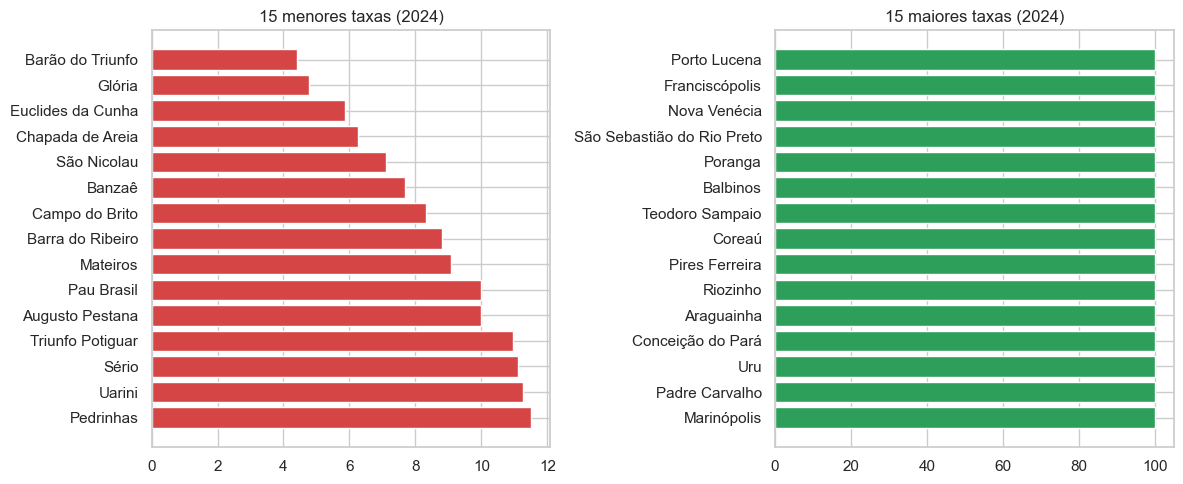

In [10]:
gold_2024 = gold[gold["ano"] == 2024].merge(municipios_ibge, on="id_municipio", how="left")
ranked = gold_2024.sort_values("taxa_alfabetizacao")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bottom = ranked.head(15)
axes[0].barh(bottom["nome_municipio"], bottom["taxa_alfabetizacao"], color="#D64545")
axes[0].set_title("15 menores taxas (2024)")
axes[0].invert_yaxis()

top = ranked.tail(15).sort_values("taxa_alfabetizacao", ascending=False)
axes[1].barh(top["nome_municipio"], top["taxa_alfabetizacao"], color="#2E9E5B")
axes[1].set_title("15 maiores taxas (2024)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 2.8 Classificação em relação à meta, por ano

classificacao  Abaixo da meta  Acima da meta  Muito abaixo da meta  Na meta  \
ano                                                                           
2023                        0              0                     0        0   
2024                      962           2752                  2390      972   

classificacao  Sem meta definida  
ano                               
2023                        7685  
2024                         477  


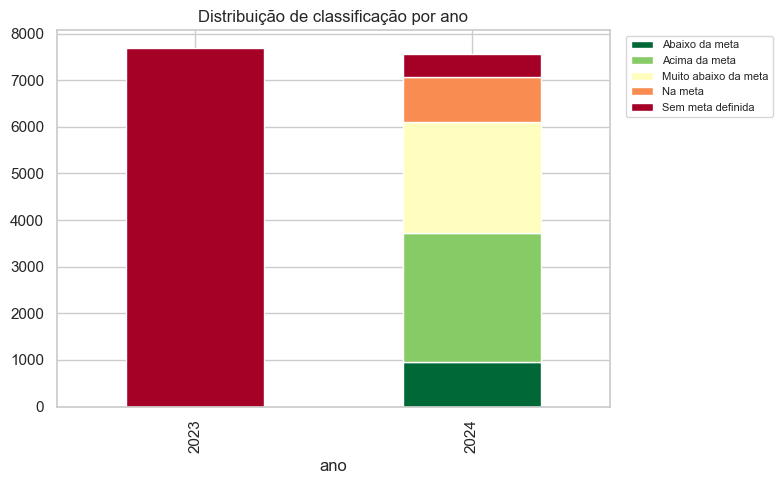

In [11]:
ct = pd.crosstab(gold["ano"], gold["classificacao"])
print(ct)

fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlGn_r")
ax.set_title("Distribuição de classificação por ano")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Leitura:** em 2023 a maioria aparece como "Sem meta definida" (meta só
existe a partir de 2024). Por isso, no notebook 03, o target principal usa
um critério que funciona nos dois anos (mediana nacional), e a meta oficial
entra como análise de sensibilidade restrita a 2024.

## 2.9 Hipóteses analíticas (para testar na modelagem)

1. **H1 — Participação isolada tem pouco poder preditivo**: correlação
   fraca (~0.28) com a taxa.
2. **H2 — O ponto de partida histórico (metas) é o fator mais informativo
   disponível**: as metas carregam informação estrutural do município.
3. **H3 — Rede de ensino pode ter algum efeito, mas não deve dominar**: as
   médias por rede são relativamente próximas nesta base.
4. **H4 — Ainda há bastante heterogeneidade não explicada**: com poucas
   features realmente independentes, o modelo deve ter um teto de
   performance moderado.
